In [160]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from FNO_vmapped import *
import pybamm
import flax
import functools
import optax

In [ ]:
MAX_ITERATION = 1337
GAMMA = 2.81
CONV_WEIGHT = 0.01

MAX_ITER1 = 100
MAX_ITER2 = 100
CONSERV_THRESHOLD = 1e-4
VOLTAGE_THRESHOLD = 1e-4

In [162]:
anode_file = "trained_models/lfp/anode_GRF_Prada2013__2025-04-08_16-03-24.msgpack"
cathode_file = "trained_models/lfp/cathode_GRF_Prada2013__2025-04-08_17-00-06.msgpack"

test_data = np.load("data/spm/for_soc/test/GRF_Prada2013_2200.npz")

In [163]:

test_I = jnp.array(test_data["current"])

test_cn_anode = jnp.array(test_data["target_concentration_anode"])

test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [164]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [165]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
hidden_channels = 64
output_channels = 1

# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

# Create dummy inputs
key_main = jax.random.PRNGKey(0)
dummy_I = jax.random.normal(key_main, (num_samples_I,))  # shape (75,)
dummy_c0 = jax.random.normal(key_main, (num_samples_c0,)) # shape (20,)

# Choose one sample for I and c0
I_single = dummy_I[0]   # scalar
c0_single = dummy_c0[0] # scalar

# Original resolutions without padding
H_orig = 20
W_orig = 75

H = H_orig + 2 * padding_r  # 20 + 2*2 = 24
W = W_orig + 2 * padding_t  # 75 + 2*5 = 85

# Pad I along t-axis (turning a scalar into a vector of length W)
# Here I_single is a scalar, we need a (W_orig,) vector. Let's assume we want a constant I for all t.
# For a single dummy run, let's just create a constant vector from I_single:
I_vector = jnp.full((W_orig,), I_single)
I_padded = jnp.pad(I_vector, (padding_t, padding_t))  # shape (85,)

# Pad c0 along r-axis (similarly create a vector from c0_single)
c0_vector = jnp.full((H_orig,), c0_single)
c0_padded = jnp.pad(c0_vector, (padding_r, padding_r))  # shape (24,)

# Create coordinate grids
r_lin = jnp.linspace(0, 1, H)  # shape (24,)
t_lin = jnp.linspace(0, 1, W)  # shape (85,)
R, T = jnp.meshgrid(r_lin, t_lin, indexing='ij')  # R,T both (24,85)

# Broadcast I_padded (85,) to (24,85)
I_2D = jnp.tile(I_padded[None, :], (H, 1))   # (24,85)
# Broadcast c0_padded (24,) to (24,85)
c0_2D = jnp.tile(c0_padded[:, None], (1, W)) # (24,85)

# Stack all channels: (B,H,W,C) with B=1
input_tensor = jnp.stack([I_2D, c0_2D, R, T], axis=-1)   # (24,85,4)
#input_tensor = input_tensor[None, ...]  # Add batch dimension: (1,24,85,4)

# Instantiate model
model = FNO(k_modes=k_modes, fno_depth=fno_depth, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
params = model.init(init_key, input_tensor)

# Forward pass
anode = model.apply(params, input_tensor)
cathode = model.apply(params, input_tensor)
print("Output shape:", anode.shape)  # should be (1,24,85,1)
print("Output shape:", cathode.shape)

Output shape: (24, 85, 1)
Output shape: (24, 85, 1)


In [166]:
def preprocess_data(train_I, train_c0, train_cn):
    """
    Pre-process the dataset into channels and padded shapes suitable for the FNO.
    
    Parameters
    ----------
    train_I : np.ndarray
        Current samples of shape (num_samples, 75).
    train_c0 : np.ndarray
        Initial concentration samples of shape (num_samples, 20).
    train_cn : np.ndarray
        Target concentrations of shape (num_samples, 20, 75).

    Returns
    -------
    X : jnp.ndarray
        Preprocessed inputs of shape (num_samples, 24, 85, 4).
    Y : jnp.ndarray
        Preprocessed targets of shape (num_samples, 24, 85, 1).
    """

    num_samples = train_I.shape[0]
    t_lin = t/t_max
    R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

    R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))
    # R, T now have shape (24,85)


    # Prepare arrays for output
    X = jnp.zeros((num_samples, H, W, 4))
    Y = jnp.zeros((num_samples, H, W, 1))

    # Pad function
    def pad_along_time(arr, padding):
        # arr shape is (..., 75)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    def pad_along_r(arr, padding):
        # arr shape is (..., 20)
        return jnp.pad(arr, ((0,0), (padding, padding)))

    # Pad I and c0 along appropriate axes
    # For each sample:
    # train_I[n]: shape (75,) -> pad to (85,)
    # train_c0[n]: shape (20,) -> pad to (24,)

    I_padded = pad_along_time(train_I, padding_t)    # (num_samples, 85)
    c0_padded = pad_along_r(train_c0, padding_r)      # (num_samples, 24)

    # Broadcast to (24,85) for each sample
    # I_padded: (num_samples, 85) -> (num_samples,24,85)
    # replicate along r-dim
    I_2D = jnp.tile(I_padded[:, None, :], (1, H, 1))

    # c0_padded: (num_samples,24) -> (num_samples,24,85)
    # replicate along t-dim
    c0_2D = jnp.tile(c0_padded[:, :, None], (1, 1, W))

    # R,T are the same for all samples, just expand
    R_3D = jnp.tile(R[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)
    T_3D = jnp.tile(T[None, ...], (num_samples, 1, 1)) # (num_samples,24,85)

    # Stack channels: (num_samples,24,85,4)
    X = jnp.stack([I_2D, c0_2D, R_3D, T_3D], axis=-1)

    # Process targets (train_cn): (num_samples,20,75)
    # pad targets along r and t to (24,85)
    # Along r: pad (20,) to (24,)
    # Along t: pad (75,) to (85,)

    # Pad cn along both dimensions:
    # We'll do this per-sample:
    cn_padded = jnp.pad(train_cn, ((0,0),(padding_r,padding_r),(padding_t,padding_t))) # (num_samples,24,85)

    # Add channel dimension for targets: (num_samples,24,85,1)
    Y = cn_padded[..., None]

    return X,Y#jax.device_put(X, cpu), jax.device_put(Y, cpu)

In [167]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [168]:
socs = [0. + i*0.01 for i in range(101)]
c0s_anode = []
c0s_cathode = []
spm = pybamm.lithium_ion.SPM()
spm.events = []
sim = pybamm.Simulation(spm, parameter_values=params_bat)
for soc in socs:
    sol = sim.solve(initial_soc=soc, t_eval = t)
    c0s_anode.append(sol["Negative particle concentration"].entries[0, 0, 0])
    c0s_cathode.append(sol["Positive particle concentration"].entries[0, 0, 0])

coeff_anode = np.polyfit(c0s_anode, socs, 1)
coeff_cathode = np.polyfit(c0s_cathode, socs, 1)

soc_from_c0_anode = lambda x: jnp.polyval(coeff_anode, x)
soc_from_c0_cathode = lambda x: jnp.polyval(coeff_cathode, x)

In [169]:
@jax.jit
def soc_to_c0(soc):
    """
    Given a state-of-charge (soc) value (scalar or array), compute the corresponding
    anode and cathode initial concentrations based on the linear fits.
    
    Returns:
        A tuple (c0_anode, c0_cathode)
    """
    c0_anode = (soc - coeff_anode[1]) / coeff_anode[0]
    c0_cathode = (soc - coeff_cathode[1]) / coeff_cathode[0]
    
    c0_anode = jnp.full((20,), c0_anode)
    c0_cathode = jnp.full((20,), c0_cathode)

    return c0_anode, c0_cathode

In [170]:
# @jax.jit
# def volume_average_c_s(r_array, c_s_array, R, cmax):
#     # We'll do a discrete integral of r^2 * c_s(r)
#     # using, e.g., np.trapz for the integral
#     r_rescaled = r_array * R
#     integrand = (r_rescaled**2) * c_s_array*cmax
#     integral = 0.5 * jnp.sum(integrand[1:] + integrand[:-1])
#     return (3.0 / R**3) * integral

In [171]:
c0s_anode = np.array(c0s_anode)
c0s_cathode = np.array(c0s_cathode)
total_li = np.mean(c0s_anode*cs_max_a*Lan*epsan*A + c0s_cathode*cs_max_c*Lca*epsca*A)
total_li

0.08831773385568002

In [172]:
conservations = []
for i in range (8800):
    conservation = (jnp.mean(test_cn_anode[i],axis=1)*cs_max_a*Lan*epsan*A + jnp.mean(test_cn_cathode[i],axis = 1)*cs_max_c*Lca*epsca*A)
    conservations.append(jnp.mean(conservation))

conservations = jnp.array(conservations)
total_li = jnp.mean(conservations)
total_li

Array(0.08834771, dtype=float32)

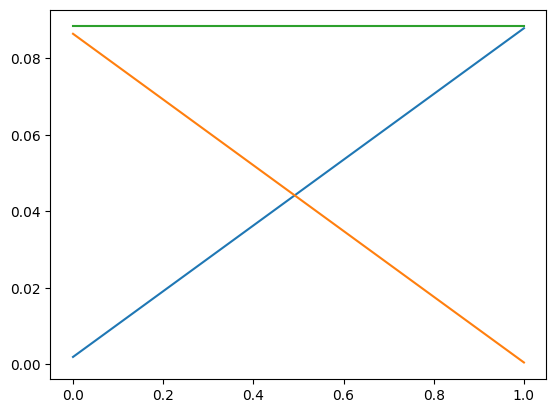

In [173]:
plt.plot(socs, c0s_anode*cs_max_a*Lan*epsan*A)
plt.plot(socs, c0s_cathode*cs_max_c*Lca*epsca*A)
plt.plot(socs, c0s_anode*cs_max_a*Lan*epsan*A + c0s_cathode*cs_max_c*Lca*epsca*A)

In [174]:
params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [175]:
test_idx = np.random.randint(0, 8800)

In [176]:
def get_dummy_measurement(I, cn_anode, cn_cathode, noise = 0, max_retries = 1000, idx = None):

    for _ in range(max_retries):

        if jnp.isnan(idx):
            test_idx = np.random.randint(0, 8800)
        else:
            test_idx = idx
            
        I_test = I[test_idx]
        cn_anode_test = cn_anode[test_idx]
        cn_cathode_test = cn_cathode[test_idx]

        _, V_true = functions.post_proc(params_bat, I_test, 0, cn_anode_test[-1,:], 0, cn_cathode_test[-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
        
        if jnp.isnan(V_true).any():
            print(V_true)
            continue
        else:
            return V_true + noise, test_idx
    
    raise ValueError("Could not produce a NaN-free measurement after {} retries.".format(max_retries))

In [177]:
def U_OCP_an(sto):
    u_eq = (
        1.9793 * jnp.exp(-39.3631 * sto)
        + 0.2482
        - 0.0909 * jnp.tanh(29.8538 * (sto - 0.1234))
        - 0.04478 * jnp.tanh(14.9159 * (sto - 0.2769))
        - 0.0205 * jnp.tanh(30.4444 * (sto - 0.6103))
    )

    return u_eq

# def U_OCP_ca(sto):
#     u_eq = (
#         -0.8090 * sto
#         + 4.4875
#         - 0.0428 * jnp.tanh(18.5138 * (sto - 0.5542))
#         - 17.7326 * jnp.tanh(15.7890 * (sto - 0.3117))
#         + 17.5842 * jnp.tanh(15.9308 * (sto - 0.3120))
#     )

#     return u_eq

#OCP Cathode LFP
def U_OCP_ca(sto):

    c1 = -150 * sto
    c2 = -30 * (1 - sto)
    k = 3.4077 - 0.020269 * sto + 0.5 * jnp.exp(c1) - 0.9 * jnp.exp(c2)

    return k


R_gas = params_bat['Ideal gas constant [J.K-1.mol-1]']
F = params_bat['Faraday constant [C.mol-1]']
Temp = params_bat["Ambient temperature [K]"]

def in_arcsinh(I, R, epsilon, L, A):

    x = I * R / (3 * epsilon * L * A)

    return x

In [178]:

t_lin = t/t_max
R_orig, T_orig = jnp.meshgrid(r, t_lin, indexing='ij')  # (20,75) each

R =jnp.pad(R_orig, ((padding_r, padding_r),(padding_t, padding_t)))
T = jnp.pad(T_orig, ((padding_r, padding_r),(padding_t, padding_t)))

In [179]:
def preprocess_candidates(I_array, c0_array):
    """
    Convert a single (or batch of) current and c0 arrays into
    padded 2D channels for the FNO: shape (B, 24, 85, 4).
    
    Parameters
    ----------
    I_array : jnp.ndarray
        If shape is (75,) => a single sample. Or (B,75) => batch.
    c0_array : jnp.ndarray
        If shape is (20,) => a single sample. Or (B,20) => batch.
    
    Returns
    -------
    X : jnp.ndarray
        FNO input, shape (B, 24, 85, 4).
        Where channels are: [I_2D, c0_2D, R_padded, T_padded].
    """
    # # 1) Ensure we have a batch dimension. If user passes shape (75,), add batch=1
    # if I_array.ndim == 1:
    #     I_array = I_array[None, :]   # shape (1,75)
    # if c0_array.ndim == 1:
    #     c0_array = c0_array[None, :] # shape (1,20)
    
    # B = I_array.shape[0]  # batch size
    
    # 2) Pad along t-axis => shape (B, 75+10) = (B,85)
    I_padded = jnp.pad(I_array, (padding_t, padding_t))  # (B,85)
    # 3) Pad along r-axis => shape (B, 20+4) = (B,24)
    c0_padded = jnp.pad(c0_array, (padding_r, padding_r)) # (B,24)

    # 4) Broadcast to (B, 24,85)
    I_2D = jnp.tile(I_padded[None, :], (H, 1))       # shape (B,24,85)
    c0_2D = jnp.tile(c0_padded[:, None], (1, W))     # shape (B,24,85)
    
    # 5) Broadcast R_padded, T_padded => shape (B,24,85)
    #    They are constant, so just replicate along batch dimension
    
    # R_3D = jnp.tile(R[None, ...], (B, 1, 1))  # (B,24,85)
    # T_3D = jnp.tile(T[None, ...], (B, 1, 1))  # (B,24,85)

    # 6) Stack channels => shape (B, 24,85,4)
    X = jnp.stack([I_2D, c0_2D, R, T], axis=-1)
    
    # print(X.shape)

    return X

In [180]:
def postprocess_candidates(c_pred: jnp.ndarray,) -> jnp.ndarray:
    eps = 1e-6
    """
    Post-process FNO output for a single electrode (anode or cathode).
    1. Removes radial/time padding (2 in r, 5 in t).
    2. Extracts the last radial index (surface).
    
    Parameters
    ----------
    c_pred : jnp.ndarray
        FNO predictions of shape (B, 24, 85, 1) for a batch size B (or B=1).

    Returns
    -------
    jnp.ndarray
        Surface concentration at the outer radial index, shape (B, W_orig).
    """
    
    # Unpad the radial and time dimensions: shape (B, 20, 75)
    c_unpadded = c_pred[
        padding_r : padding_r + H_orig,
        padding_t : padding_t + W_orig,
        0
    ]

    # Take the last radial index => surface concentration, shape (B, 75)
    c_surface = c_unpadded[-1, :]


    #These values can be negative. Because they are going to be part in a square root we filter out negative values in order to avoid nans
    # c_surface = jnp.maximum(c_surface, eps)
    c_surface = jnp.clip(c_surface,eps,1-eps)

    return c_surface


In [181]:

def fno_predict_voltage(c0_anode, c0_cathode, current):
# def post_proc(params, I_c, c_pred_an, c_true_an, c_pred_ca, c_true_ca, Ran, Rca, epsan, epsca, Lan, Lca, A):

    X_anode = preprocess_candidates(current,c0_anode)
    X_cathode = preprocess_candidates(current,c0_cathode)

    cn_anode = model.apply(params_anode,X_anode)
    cn_cathode = model.apply(params_cathode,X_cathode)
    
    cn_anode_surf = postprocess_candidates(cn_anode)
    cn_cathode_surf = postprocess_candidates(cn_cathode)

    j_anode = cn_anode_surf**0.5 * (1-cn_anode_surf)**0.5
    j_cathode = cn_cathode_surf**0.5 * (1-cn_cathode_surf)**0.5

    xan = in_arcsinh(-current, Ran, epsan, Lan, A)
    xca = in_arcsinh(-current, Rca, epsca, Lca, A)

    V_pred = U_OCP_ca(cn_cathode_surf) - U_OCP_an(cn_anode_surf) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xan/(j_anode)) - 2 * R_gas*Temp/F * jnp.arcsinh(0.5*xca/(j_cathode))

    return V_pred

In [182]:
def fno_predict_concentrations(c0_anode, c0_cathode, current):
# def post_proc(params, I_c, c_pred_an, c_true_an, c_pred_ca, c_true_ca, Ran, Rca, epsan, epsca, Lan, Lca, A):

    X_anode = preprocess_candidates(current,c0_anode)
    X_cathode = preprocess_candidates(current,c0_cathode)

    cn_anode = model.apply(params_anode,X_anode)
    cn_cathode = model.apply(params_cathode,X_cathode)
    
    cn_anode = cn_anode[padding_r : padding_r + H_orig,padding_t : padding_t + W_orig,0]
    cn_cathode = cn_cathode[padding_r : padding_r + H_orig,padding_t : padding_t + W_orig,0]
    
    return cn_anode, cn_cathode

batch_fno_predict_concentrations = jax.vmap(fno_predict_concentrations, in_axes = (0, 0, None), out_axes=0)

In [183]:
######Jetzt gehts los######

batch_size = 100

V_meas, test_idx = get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise = 0, idx = 1)


In [184]:
_, V_1 = functions.post_proc(params_bat, test_I[test_idx], 0, test_cn_anode[test_idx,-1,:], 0, test_cn_cathode[test_idx,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)

In [185]:
V_2 = fno_predict_voltage(test_c0_anode[test_idx], test_c0_cathode[test_idx], test_I[test_idx])

In [186]:
can, cca = fno_predict_concentrations(test_c0_anode[test_idx], test_c0_cathode[test_idx], test_I[test_idx])

In [187]:
np.mean(np.abs(can - test_cn_anode[test_idx]))

0.00034757392

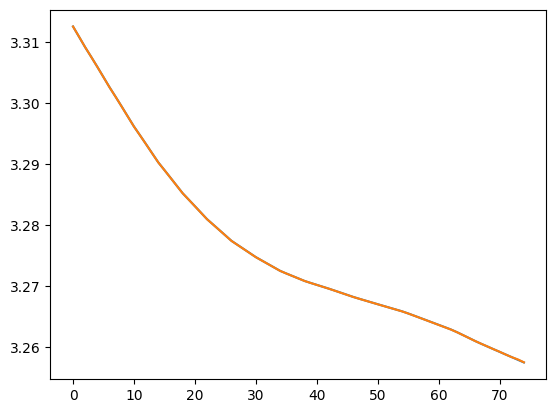

In [188]:
plt.plot(V_1)
plt.plot(V_2)

In [189]:
target_current = test_I[test_idx]

In [190]:

@jax.jit
# @functools.partial(jax.vmap, in_axes=(0, 0, None, None), out_axes=0)
def objective_fn_forward(c0_anode, c0_cathode, current, V_meas):

    gamma = GAMMA
    # Predict shape (1,75)
    # current_batch = jnp.tile(current[None,...], (batch_size, 1))
    # V_meas_batch = jnp.tile(V_meas[None,...], (batch_size, 1))

    V_pred = fno_predict_voltage(c0_anode, c0_cathode, current)
    # V_pred = jax.vmap(fno_predict_voltage(c0_anode, c0_cathode, current), in_axes=(0, 0, None, None))
    # mask_nans = jnp.isnan(V_pred).any(axis=1)

    # if jnp.any(mask_nans):
    #     c0_batch = reinit_guesses(c0_batch, mask_nans, key)
    conservation_losses_squared = (jnp.repeat(total_li,num_samples_I) - (jnp.mean(c0_anode,axis=0)*cs_max_a*Lan*epsan*A + jnp.mean(c0_anode,axis=0)*cs_max_c*Lca*epsca*A))**2
    conservation_loss = jnp.mean(conservation_losses_squared)
    residuals_squared = (V_pred - V_meas)**2  # shape (75,)
    # 4) Temporal causality gating:
    #    We define gating[t] = exp(- gamma * sum_{k=0}^{t-1} L[k])
    #    so that the model focuses on early times until they're learned
    #    (i.e., once sum_{k=0}^{t-1} L[k] is small, gating[t] becomes ~1).
    cumsum_losses = jnp.cumsum(residuals_squared)  # shape (T,), cumsum of L up to each step
    raw_gating_factors = jnp.exp(-gamma * cumsum_losses)
    gating_factors = jax.lax.stop_gradient(raw_gating_factors)  # shape (T,)

    # 5) Weighted per-time-step losses
    L_weighted = gating_factors * residuals_squared  # shape (T,)

    # 6) Final objective: (weighted MSE) + conservation_loss
    #    Often you might do sum or mean. Here we do mean for convenience.
    mse_temporal_causal = jnp.mean(L_weighted)
    total_loss = mse_temporal_causal + conservation_loss*CONV_WEIGHT
    
    return total_loss

In [191]:
@jax.jit
def conservation_objective_fn(c0_an, c0_ca, current):
    """
    Compute the squared difference between the target total lithium 
    (total_li) and the sum of the (integrated) lithium contents
    obtained from the anode and cathode concentration fields.
    """
    can, cca = fno_predict_concentrations(c0_an, c0_ca, current)
    # Note: Adjusted second term to use c0_ca for the cathode.
    integrated_li = jnp.mean(can, axis=0) * cs_max_a * Lan * epsan * A + \
                    jnp.mean(cca, axis=0) * cs_max_c * Lca * epsca * A
    loss = (jnp.repeat(total_li, num_samples_I) - integrated_li) ** 2
    return jnp.mean(loss)


@jax.jit
def voltage_objective_fn(c0_an, c0_ca, current, V_meas):
    """
    Compute the temporal causality–weighted voltage prediction loss.
    """
    # Predict voltage; assumed shape is (T,) where T == num_samples_I
    V_pred = fno_predict_voltage(c0_an, c0_ca, current)
    residuals_squared = (V_pred - V_meas) ** 2
    # Compute cumulative loss along time to enforce temporal causality:
    cumsum_losses = jnp.cumsum(residuals_squared)
    raw_gating_factors = jnp.exp(-GAMMA * cumsum_losses)
    # Stop gradient on gating to keep them fixed during backprop:
    gating_factors = jax.lax.stop_gradient(raw_gating_factors)
    weighted_losses = gating_factors * residuals_squared
    return jnp.mean(weighted_losses)

In [192]:
conserv_lr = 1e-4
conserv_optimizer = optax.adam(learning_rate=conserv_lr)

@jax.jit
def stage1_inner_loop(state, current, V_meas, max_iterations = MAX_ITERATION):
    """
    Inner loop to enforce charge conservation.
    
    state: (c0_an, c0_ca, opt_state_an, opt_state_ca, iter, loss)
    """
    def cond_fn(state):
        _, _, _, _, it, loss = state
        return jnp.logical_and(loss > CONSERV_THRESHOLD, it < max_iterations)
    
    def body_fn(state):
        c0_an, c0_ca, opt_state_an, opt_state_ca, it, _ = state
        loss, (grad_an, grad_ca) = jax.value_and_grad(conservation_objective_fn, argnums=(0, 1))(c0_an, c0_ca, current)
        updates_an, new_opt_state_an = conserv_optimizer.update(grad_an, opt_state_an, c0_an)
        updates_ca, new_opt_state_ca = conserv_optimizer.update(grad_ca, opt_state_ca, c0_ca)
        new_c0_an = optax.apply_updates(c0_an, updates_an)
        new_c0_ca = optax.apply_updates(c0_ca, updates_ca)
        return (new_c0_an, new_c0_ca, new_opt_state_an, new_opt_state_ca, it + 1, loss)
    
    return jax.lax.while_loop(cond_fn, body_fn, state)

In [193]:
voltage_lr = 1e-6
voltage_optimizer = optax.adam(learning_rate=voltage_lr)

@jax.jit
def stage2_inner_loop(state, current, V_meas, max_iterations):
    """
    Inner loop for voltage difference minimization.
    
    Optionally, you can include a small conservation penalty to ensure you do not
    move out of the conservation subspace, but here we focus solely on the voltage loss.
    
    state: (c0_an, c0_ca, opt_state_an, opt_state_ca, iter, loss)
    """
    def cond_fn(state):
        _, _, _, _, it, loss = state
        return jnp.logical_and(loss > VOLTAGE_THRESHOLD, it < max_iterations)
    
    def body_fn(state):
        c0_an, c0_ca, opt_state_an, opt_state_ca, it, _ = state
        loss = voltage_objective_fn(c0_an, c0_ca, current, V_meas)
        grad_an, grad_ca = jax.grad(lambda an, ca: voltage_objective_fn(an, ca, current, V_meas), argnums=(0, 1))(c0_an, c0_ca)
        updates_an, new_opt_state_an = voltage_optimizer.update(grad_an, opt_state_an, c0_an)
        updates_ca, new_opt_state_ca = voltage_optimizer.update(grad_ca, opt_state_ca, c0_ca)
        new_c0_an = optax.apply_updates(c0_an, updates_an)
        new_c0_ca = optax.apply_updates(c0_ca, updates_ca)
        return (new_c0_an, new_c0_ca, new_opt_state_an, new_opt_state_ca, it + 1, loss)
    
    return jax.lax.while_loop(cond_fn, body_fn, state)

In [194]:
@jax.jit
def soc_search_jax(c0_an_init, c0_ca_init, current, V_meas):
    """
    Run a nested optimization:
      1) Stage 1: Optimize for charge conservation with a high learning rate.
      2) Stage 2: Starting in the subspace where conservation is (nearly) satisfied,
         optimize for minimal voltage difference.
         
    c0_an_init, c0_ca_init: initial concentration conditions.
    current, V_meas: Input current profile and measured voltage.
    
    Returns:
      Final optimized (c0_an, c0_ca) along with the final losses from stage 1 and stage 2.
    """
    # Stage 1: Charge conservation stage.
    opt_state_an = conserv_optimizer.init(c0_an_init)
    opt_state_ca = conserv_optimizer.init(c0_ca_init)
    init_state = (c0_an_init, c0_ca_init, opt_state_an, opt_state_ca, 0, jnp.inf)
    stage1_state = stage1_inner_loop(init_state, current, V_meas, max_iterations=MAX_ITER1)
    c0_an_stage1, c0_ca_stage1, _, _, it1, loss_conserv = stage1_state
    
    # Stage 2: Voltage difference minimization stage.
    opt_state_an2 = voltage_optimizer.init(c0_an_stage1)
    opt_state_ca2 = voltage_optimizer.init(c0_ca_stage1)
    init_state2 = (c0_an_stage1, c0_ca_stage1, opt_state_an2, opt_state_ca2, 0, jnp.inf)
    stage2_state = stage2_inner_loop(init_state2, current, V_meas, max_iterations=MAX_ITER2)
    c0_an_final, c0_ca_final, _, _, it2, loss_voltage = stage2_state

    return c0_an_final, c0_ca_final, loss_conserv, loss_voltage

In [195]:
def sample_gaussian_random_field(key, n=20, length_scale=12.0, variance=1.0, jitter=1e-6):
    """
    Sample a smooth 1D Gaussian random field.
    
    Args:
      key: JAX PRNG key.
      n: The number of grid points (output shape will be (n,)).
      length_scale: Controls the smoothness; larger values produce smoother fields.
      variance: Variance of the field.
      jitter: Small number added to the diagonal for numerical stability.
    
    Returns:
      A jnp.ndarray of shape (n,) representing a smooth random field.
    """
    # Create an index grid.
    x = jnp.linspace(0, n - 1, n)
    # Compute the squared distance matrix.
    dx = x[:, None] - x[None, :]
    # Construct the covariance matrix using a squared exponential kernel.
    cov = variance * jnp.exp(-0.5 * (dx / length_scale) ** 2)
    cov += jitter * jnp.eye(n)  # Add jitter for stability.
    
    # Compute the Cholesky decomposition.
    L = jnp.linalg.cholesky(cov)
    
    # Sample from a standard normal distribution.
    z = jax.random.normal(key, shape=(n,))
    
    # Produce the Gaussian random field.
    sample = jnp.dot(L, z)
    return sample

In [196]:

def sample_initial_guesses(key, batch_size=1000, anode_dim=20, cathode_dim=20,
                           lower_bound=0.0, upper_bound=1.0, soc = False):
    """
    Efficiently samples initial guesses for anode and cathode concentrations.
    
    Args:
      key: A JAX PRNGKey.
      batch_size: Number of initial guesses to generate (default 1000).
      anode_dim: Dimension of the anode concentration vector (default 20).
      cathode_dim: Dimension of the cathode concentration vector (default 20).
      lower_bound: Lower bound for the uniform sampling (default 0.0).
      upper_bound: Upper bound for the uniform sampling (default 1.0).
      
    Returns:
      A tuple (c0_anode, c0_cathode) where:
        - c0_anode is a jnp.ndarray of shape (batch_size, anode_dim)
        - c0_cathode is a jnp.ndarray of shape (batch_size, cathode_dim)
    """
    if soc == False:
      # Split the key into two for anode and cathode.
      key_an, key_ca = jax.random.split(key)
      # Create a batch of keys for each electrode.
      keys_an = jax.random.split(key_an, batch_size)
      keys_ca = jax.random.split(key_ca, batch_size)
      
      # Use vmap to generate a batch of smooth samples.
      c0_anode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=anode_dim, 
                                                                  length_scale=42.0, 
                                                                  variance=1.0))(keys_an)
      c0_cathode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=cathode_dim, 
                                                                    length_scale=42.0, 
                                                                    variance=1.0))(keys_ca)

      # # Use vmap to generate a batch of smooth samples.
      # c0_anode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=anode_dim))(keys_an)
      # c0_cathode = jax.vmap(lambda k: sample_gaussian_random_field(k, n=cathode_dim))(keys_ca)
      
      c0_anode = jax.nn.sigmoid(c0_anode)  #this smoothly ensures 0 and 1 bounds
      c0_cathode = jax.nn.sigmoid(c0_cathode)
    else:
      keys_batch = jax.random.split(key, batch_size)
      socs = jax.vmap(lambda k: jax.random.uniform(k,minval=lower_bound, maxval = upper_bound))(keys_batch)
      return socs

    return c0_anode, c0_cathode



In [197]:
key_sampling = jax.random.PRNGKey(314)
c0_anode_initial, c0_cathode_initial = sample_initial_guesses(key_sampling, batch_size=batch_size)
# socs_initial = sample_initial_guesses(key_sampling, batch_size=batch_size, soc = True)

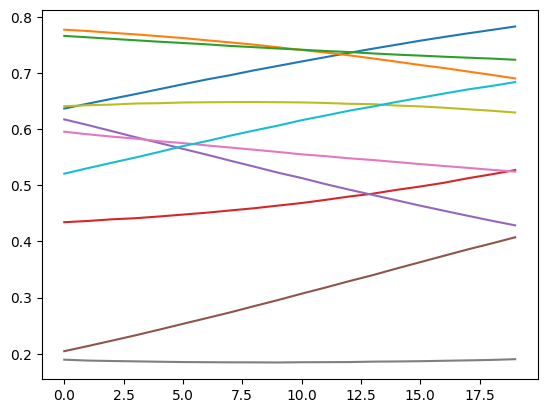

In [198]:
plt.plot(c0_anode_initial[:10].T)

In [199]:
learning_rate = 1e-3
run_batch_search = jax.vmap(soc_search_jax, in_axes=(0,0, None, None), out_axes=0)
# run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
c0_anode_sol, c0_cathode_sol, _, loss = run_batch_search(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
# c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)


In [200]:
best_idx = loss.argmin()
best_idx

Array(24, dtype=int32)

In [201]:
worst_idx = loss.argmax()
loss[worst_idx]

Array(0.01045175, dtype=float32)

In [202]:
loss[best_idx]

Array(1.6148489e-07, dtype=float32)

In [203]:
V_pred2 = fno_predict_voltage(c0_anode_sol[best_idx,:].reshape(-1),c0_cathode_sol[best_idx,:].reshape(-1),target_current)

In [204]:
V_pred3 = fno_predict_voltage(test_c0_anode[test_idx,:].reshape(-1),test_c0_cathode[test_idx,:].reshape(-1),target_current)

In [205]:
V_worst = fno_predict_voltage(c0_anode_sol[worst_idx,:].reshape(-1),c0_cathode_sol[worst_idx,:].reshape(-1),target_current)

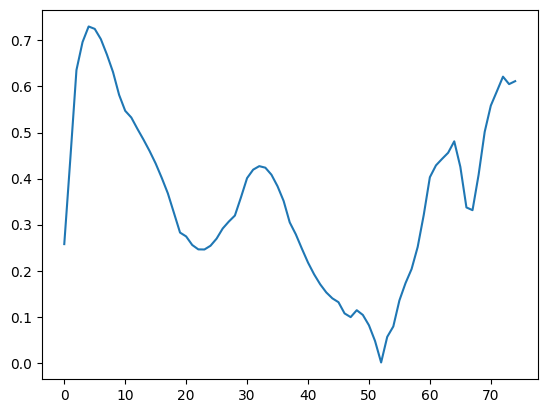

In [206]:
plt.plot(np.abs(V_meas-V_pred2) * 1000)

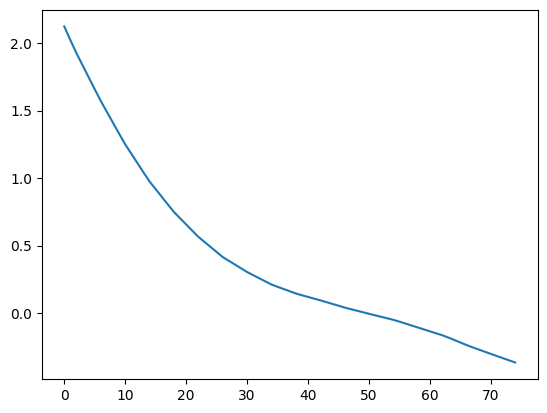

In [207]:
plt.plot(target_current)

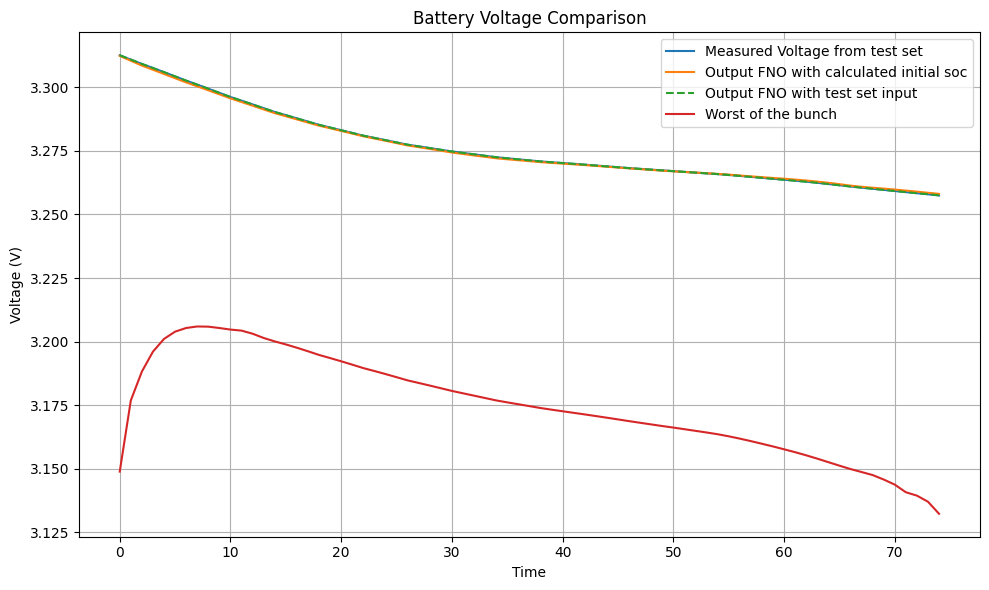

In [208]:
# Create a figure with a larger size for clarity
plt.figure(figsize=(10, 6))

# Plot the voltage data with labels for the legend
plt.plot(V_meas, label="Measured Voltage from test set")
plt.plot(V_pred2, label="Output FNO with calculated initial soc")
plt.plot(V_pred3, linestyle = "--", label="Output FNO with test set input")
plt.plot(V_worst, label="Worst of the bunch")

# Label axes and add a title
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Battery Voltage Comparison")

# Set y-axis limits based on battery parameters from pybamm
#plt.ylim(params_bat["Lower voltage cut-off [V]"], params_bat["Upper voltage cut-off [V]"])

# Add grid lines and legend
plt.grid(True)
plt.legend()

# Adjust layout for better spacing and display the plot
plt.tight_layout()
plt.show()

In [209]:
c0_av = jnp.mean(c0_anode_sol[best_idx])
soc_pred = soc_from_c0_anode(c0_av)

In [210]:
soc_true = soc_from_c0_anode(jnp.mean(test_c0_anode[test_idx]))
soc_true

Array(0.3388251, dtype=float32)

In [211]:
soc_cathode_pred = soc_from_c0_cathode(jnp.mean(c0_cathode_sol[best_idx]))
soc_cathode_pred

Array(0.3631603, dtype=float32)

In [212]:
soc_cathode_true = soc_from_c0_cathode(jnp.mean(test_c0_cathode[test_idx]))
soc_cathode_true

Array(0.4578886, dtype=float32)

In [238]:
can, cca = fno_predict_concentrations(c0_anode_sol[best_idx], c0_cathode_sol[best_idx], target_current)

In [ ]:
an_diff = np.abs(can - test_cn_anode[test_idx,:])
ca_diff = np.abs(cca - test_cn_cathode[test_idx,:])

In [250]:
(np.mean(an_diff) + np.mean(ca_diff))/2

Array(0.32719225, dtype=float32)

In [213]:
soc_pred-soc_true

Array(0.17268652, dtype=float32)

In [214]:
c0_av = jnp.mean(c0_anode_sol[worst_idx])
soc_from_c0_anode(c0_av) - soc_true

Array(-0.1920328, dtype=float32)

In [215]:
np.savez("plots/boxplot/loss_fno.npz",loss)

In [216]:
concentration_estimates_anode = []
concentration_estimates_cathode = []

In [217]:
# @jax.jit
def all_calc(c0_anode_initial, c0_cathode_initial, target_current, V_meas):
    c0_anode_sol, c0_cathode_sol, _, loss = run_batch_search(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
    #print(c0_anode_sol.shape)
    cn_anode_sol, cn_cathode_sol = batch_fno_predict_concentrations(c0_anode_sol, c0_cathode_sol, target_current)

    return c0_anode_sol, c0_cathode_sol, loss, cn_anode_sol, cn_cathode_sol

In [218]:
key = jax.random.PRNGKey(43)
num_cases = 40
sampled_indices = jax.random.permutation(key, test_I.shape[0])[:num_cases]
target_currents = test_I[sampled_indices]

V_measures = jax.vmap(fno_predict_voltage, in_axes=(0,0,0), out_axes=0)(test_c0_anode[sampled_indices], test_c0_cathode[sampled_indices],target_currents)
_, V_trues = functions.post_proc(params_bat, target_currents, 0, test_cn_anode[sampled_indices,-1,:], 0, test_cn_cathode[sampled_indices,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)
# Define a tolerance for float comparisons (adjust as needed)
tol = 1e-2

# Create a boolean mask that checks if all 75 elements in each row are within the tolerance.
correct_mask = jnp.all(jnp.abs(V_measures - V_trues) < tol, axis=1)

# Filter the V_measures and the sampled indices using the boolean mask.
V_measures_correct = V_measures[correct_mask]
target_currents_correct = target_currents[correct_mask]
sampled_indices_correct = sampled_indices[correct_mask]

print("Number of samples with correct predictions:", V_measures_correct.shape[0])

Number of samples with correct predictions: 26


In [ ]:
import time
import jax
import jax.numpy as jnp

# Assumptions:
# - test_I is an array of currents with shape (8800, 75)
# - get_dummy_measurement(test_I, test_cn_anode, test_cn_cathode, noise, idx)
#   returns a tuple (V_meas, test_idx)
# - sample_initial_guesses(key, batch_size, soc=True) returns a SOC initial guess
#   with shape (batch_size,) (or (batch_size, ...) as required)
# - soc_search_jax_soc is your function that takes (soc_init, current, V_meas)
#   and returns (c0_anode, c0_cathode, loss), where loss is an array (one loss per sample)
# - batch_size is defined

# Set up a key and sample 10 random indices from test_I:
batch_size = 50
run = 0
times = []
all_min_losses = []
socs_pred = []
socs_true = soc_from_c0_anode(jnp.mean(test_c0_anode[sampled_indices_correct],axis=1))

concentration_true_anode, concentration_true_cathode = jax.vmap(fno_predict_concentrations,in_axes=(0,0,0),out_axes=0)(test_c0_anode[sampled_indices_correct], test_c0_cathode[sampled_indices_correct], target_currents_correct)

# Initialize a key for SOC sampling. We'll update it in each iteration.
key_sampling = jax.random.PRNGKey(100)
run_best_losses = []  # store best loss per current in this run
# run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
# Loop over the 10 sampled currents
for V_meas, target_current in zip(V_measures_correct, target_currents_correct):
    run = run + 1
    run_start = time.time()
    # Get the dummy measurement for the current sample.
    
    # Generate a new key for the SOC initial guesses.
    key_sampling, subkey = jax.random.split(key_sampling)
    c0_anode_initial, c0_cathode_initial = sample_initial_guesses(subkey, batch_size=batch_size)
    
    # Vectorize the SOC search function over the batch dimension.
    #run_batch_search = jax.vmap(soc_search_jax_soc, in_axes=(0, None, None), out_axes=0)
    # c0_anode_sol, c0_cathode_sol, loss = run_batch_search(socs_initial, target_current, V_meas)
    # cn_anode_sol, cn_cathode_sol = batch_fno_predict_concentrations(c0_anode=c0_anode_sol, c0_cathode=c0_cathode_sol, current=target_current)
    # concentration_estimates_anode.append(cn_anode_sol)
    # concentration_estimates_cathode.append(cn_cathode_sol)
    #print(socs_initial.shape)

    c0_anode_sol, c0_cathode_sol, loss, cn_anode_sol, cn_cathode_sol = all_calc(c0_anode_initial, c0_cathode_initial, target_current, V_meas)
    concentration_estimates_anode.append(cn_anode_sol[loss.argmin()])
    concentration_estimates_cathode.append(cn_cathode_sol[loss.argmin()])

    # Accuracy metric: minimal loss across the batch.
    best_loss = loss[jnp.argmin(loss)]
    socs_pred.append(soc_from_c0_anode(jnp.mean(c0_anode_sol[jnp.argmin(loss)])))

    run_best_losses.append(best_loss)

    run_time = time.time() - run_start

    times.append(run_time)

    print(f"Run {run}: Time = {run_time:.3f} s, Best Loss = {best_loss}")

avg_time = sum(times[1:]) / len(times[1:])
print("Average run time over", num_cases, "runs:", avg_time)


Run 1: Time = 35.992 s, Best Loss = 3.362504139658995e-05
Run 2: Time = 35.993 s, Best Loss = 2.2975976321504277e-07
Run 3: Time = 36.010 s, Best Loss = 3.1886618671705946e-05
Run 4: Time = 35.997 s, Best Loss = 1.1954438377870247e-05
Run 5: Time = 35.997 s, Best Loss = 5.1758644985966384e-05
Run 6: Time = 35.998 s, Best Loss = 1.5055226867843885e-05
Run 7: Time = 36.001 s, Best Loss = 4.723935489892028e-06
Run 8: Time = 36.000 s, Best Loss = 3.381982764949498e-07
Run 9: Time = 36.003 s, Best Loss = 1.6872593278094428e-06
Run 10: Time = 36.002 s, Best Loss = 5.864481136086397e-05
Run 11: Time = 36.007 s, Best Loss = 2.2970407371758483e-06
Run 12: Time = 36.004 s, Best Loss = 2.2904976503923535e-05
Run 13: Time = 36.002 s, Best Loss = 3.069157855861704e-06
Run 14: Time = 36.001 s, Best Loss = 1.0799270967254415e-05
Run 15: Time = 36.000 s, Best Loss = 1.641888593439944e-05
Run 16: Time = 35.997 s, Best Loss = 2.446635107844486e-06
Run 17: Time = 35.999 s, Best Loss = 2.3106920252757845e

In [220]:
np.savez("lfp_output/" + parameter_name + "/loss_fno_benchmark.npz",run_best_losses)

{'whiskers': [<matplotlib.lines.Line2D at 0x70ff840e2950>,
 'caps': [<matplotlib.lines.Line2D at 0x70ff840e0790>,
 'boxes': [<matplotlib.lines.Line2D at 0x70ff840e1190>],
 'medians': [<matplotlib.lines.Line2D at 0x70ff840d6a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x70ff840d79d0>],
 'means': []}

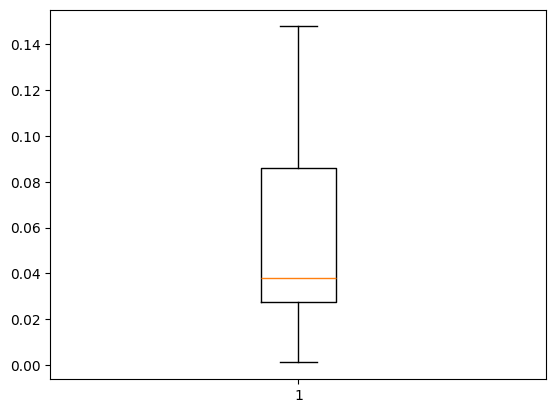

In [221]:
plt.boxplot(np.abs(np.array(socs_pred)-socs_true))

In [222]:
concentration_estimates_anode = jnp.array(concentration_estimates_anode)
concentration_estimates_cathode = jnp.array(concentration_estimates_cathode)

concentration_diffs_anode = concentration_estimates_anode-concentration_true_anode
concentration_diffs_cathode = concentration_estimates_cathode-concentration_true_cathode

In [223]:
mean_abs_error_per_batch = (np.mean(np.abs(concentration_diffs_anode*cs_max_a), axis = (1,2)) + np.mean(np.abs(concentration_diffs_cathode*cs_max_c), axis = (1,2)))/2
mean_rel_error_per_batch = np.mean((np.abs(concentration_diffs_anode) + np.abs(concentration_diffs_cathode))/2,axis = (1,2))

{'whiskers': [<matplotlib.lines.Line2D at 0x70ff7bf4f610>,
 'caps': [<matplotlib.lines.Line2D at 0x70ffaabfacd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x70ff7bf4ebd0>],
 'medians': [<matplotlib.lines.Line2D at 0x70ffaabfbc90>],
 'fliers': [<matplotlib.lines.Line2D at 0x70ffaabbae10>],
 'means': []}

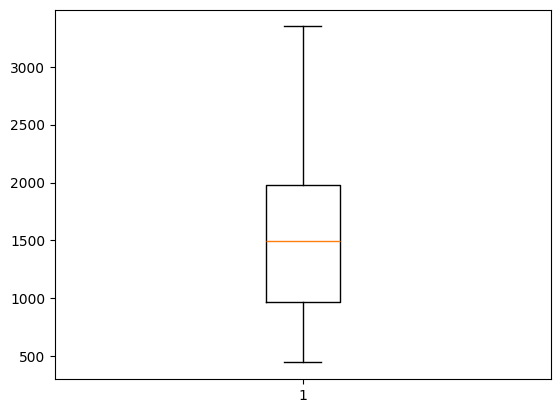

In [224]:
plt.boxplot(mean_abs_error_per_batch)


In [225]:
mean_abs_error_per_batch

array([1793.1141 , 1316.2277 , 1970.9341 , 1223.7064 , 2663.7112 ,
       3347.897  , 1609.3635 ,  630.9545 , 1467.3904 ,  938.3206 ,
       1364.2391 , 3316.2534 , 2058.0862 ,  743.27966, 1520.0841 ,
       1929.8025 ,  800.311  ,  811.578  ,  446.6216 , 2630.4023 ,
       2375.3018 , 1321.8892 , 1561.484  ,  939.4192 , 1983.957  ,
       1057.4681 ], dtype=float32)

{'whiskers': [<matplotlib.lines.Line2D at 0x70ff7b508950>,
 'caps': [<matplotlib.lines.Line2D at 0x70ff7b509d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x70ffaa1125d0>],
 'medians': [<matplotlib.lines.Line2D at 0x70ff7b50aed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x70ff7b50b750>],
 'means': []}

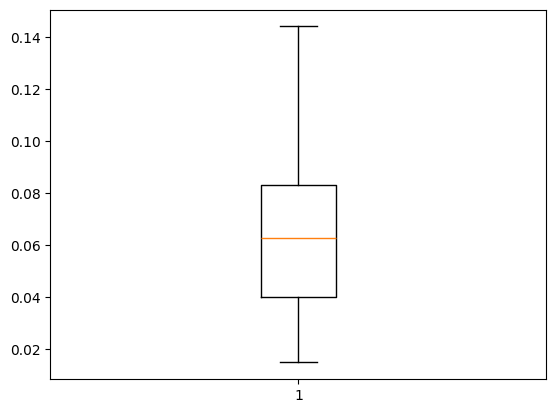

In [226]:
plt.boxplot(mean_rel_error_per_batch)

In [227]:
np.mean(mean_rel_error_per_batch)

0.06494348

In [228]:
np.savez("lfp_output/" + parameter_name + "/mean_abs_concentration_error_" + str(MAX_ITERATION) + "_" + str(GAMMA) + "_.npz",mean_abs_error_per_batch)
np.savez("lfp_output/" + parameter_name + "/mean_rel_concentration_error_" + str(MAX_ITERATION) + "_" + str(GAMMA) + "_.npz",mean_rel_error_per_batch)

In [229]:
idd = mean_abs_error_per_batch.argmax()

In [230]:
_, V_true_worst = functions.post_proc(params_bat, target_currents_correct[idd], 0, np.array(concentration_estimates_anode)[idd,-1,:], 0, np.array(concentration_estimates_cathode)[idd,-1,:], Ran, Rca, epsan, epsca, Lan, Lca, A)

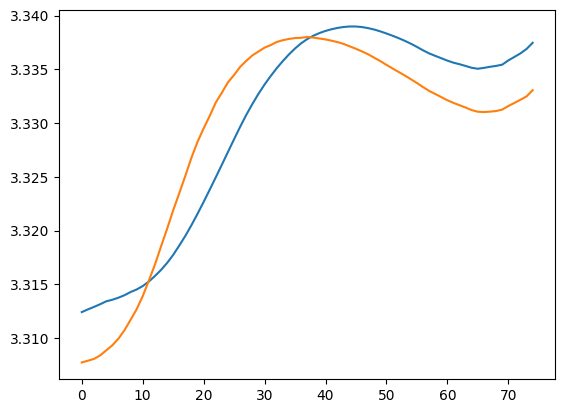

In [231]:
# plt.plot((V_measures_correct[idd]- V_true_worst)*1000)
plt.plot(V_measures_correct[idd])
plt.plot(V_true_worst)
#plt.plot(V_measures[idd])

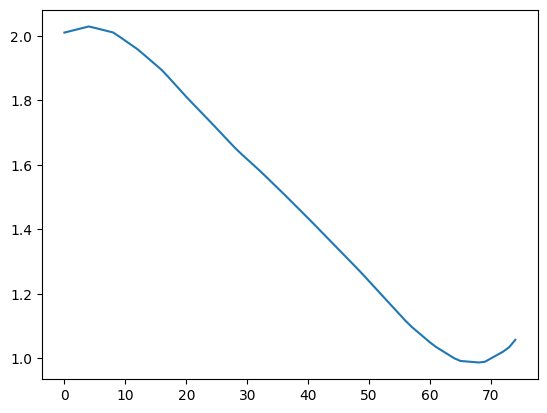

In [232]:
plt.plot(target_currents_correct[idd])

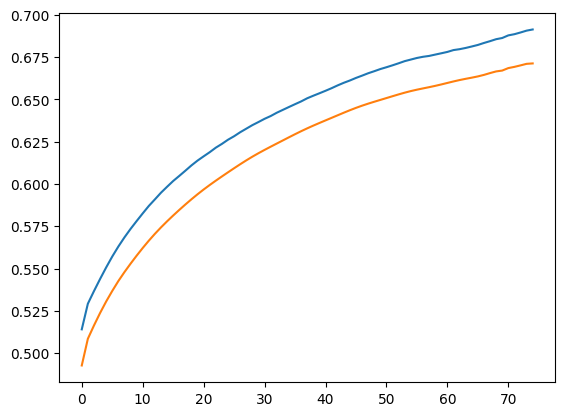

In [233]:
plt.plot(concentration_estimates_anode[idd,-1,:])
plt.plot(concentration_true_anode[idd,-1,:])

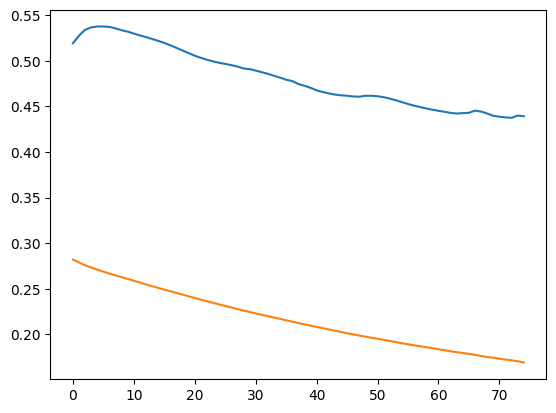

In [234]:
plt.plot(concentration_estimates_cathode[idd,-1,:])
plt.plot(concentration_true_cathode[idd,-1,:])

In [235]:
concentration_true_cathode[idd,-1,:]

Array([0.28191632, 0.27884185, 0.2757338 , 0.2731895 , 0.2709139 ,
       0.2686727 , 0.26657307, 0.26459482, 0.26266548, 0.2607205 ,
       0.25873446, 0.25672242, 0.25472045, 0.25276187, 0.25086042,
       0.24900705, 0.24717884, 0.24535298, 0.24351823, 0.24167818,
       0.2398467 , 0.23803887, 0.2362628 , 0.2345168 , 0.23279274,
       0.23108293, 0.22938627, 0.22771041, 0.22606796, 0.2244695 ,
       0.22291662, 0.22139934, 0.21989931, 0.21839774, 0.21688385,
       0.21536005, 0.21384059, 0.21234466, 0.21088694, 0.20946988,
       0.20808282, 0.2067072 , 0.20532678, 0.20393677, 0.20254803,
       0.20118304, 0.19986546, 0.19860838, 0.1974065 , 0.19623679,
       0.19506833, 0.19387639, 0.19265465, 0.19141886, 0.19019945,
       0.18902655, 0.1879134 , 0.18684837, 0.18579957, 0.184732  ,
       0.18362904, 0.18250641, 0.18140864, 0.18038382, 0.17944497,
       0.17853409, 0.17750992, 0.17617597, 0.17513815, 0.17425953,
       0.17326228, 0.1722493 , 0.1714652 , 0.17038624, 0.16909

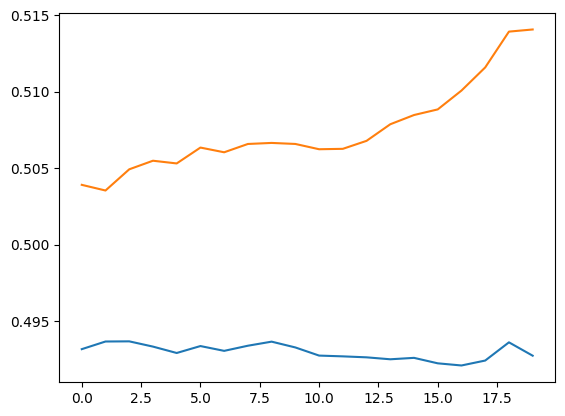

In [251]:
plt.plot(concentration_true_anode[idd,:,0].T)
plt.plot(concentration_estimates_anode[idd,:,0].T)